In [ ]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

DEVICE = cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import zipfile
#zip_path = "/content/drive/MyDrive/Dyno/semantic_annotations.zip"
#extract_path = "/content/data/masks"
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #zip_ref.extractall(extract_path)

In [ ]:
#zip_path1 = "/content/drive/MyDrive/Dyno/bigrgb_images.zip"
#extract_path1 = "/content/data/rgb"
#with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
 #   zip_ref.extractall(extract_path1)

In [ ]:
# ======= EDIT THESE PATHS =======
REAL_IMG_DIR  = "/content/data/rgb"   # ton dossier images
REAL_MASK_DIR = "/content/data/masks/semantic_annotations/rgbLabels"

# ======= TASK CONFIG =======
NUM_CLASSES   = 10         # à adapter à ton dataset
IGNORE_INDEX  = 255        # souvent 255 pour "void" (si applicable)
IMG_SIZE      = 518        # DINOv2 aime bien 518 (multiple de 14). Tu peux mettre 448/518.
BATCH_SIZE    = 4
LR            = 1e-3
EPOCHS        = 5          # augmente ensuite
NUM_WORKERS   = 2

In [ ]:
import glob, os

imgs = []
for ext in ["png","jpg","jpeg","webp"]:
    imgs += glob.glob(f"{REAL_IMG_DIR}/**/*.{ext}", recursive=True)

masks = glob.glob(f"{REAL_MASK_DIR}/**/*.png", recursive=True)

print("Nb images:", len(imgs))
print("Nb masks :", len(masks))
print("Example img :", imgs[0] if imgs else None)
print("Example mask:", masks[0] if masks else None)

Nb images: 1353
Nb masks : 8234
Example img : /content/data/rgb/rgb_images/01174_RV.png
Example mask: /content/data/masks/semantic_annotations/rgbLabels/06301_MVL.png


In [ ]:
def list_pairs_by_basename(img_dir, mask_dir):
    import glob, os

    # index masks by basename
    mask_files = glob.glob(f"{mask_dir}/**/*.png", recursive=True)
    mask_map = {os.path.splitext(os.path.basename(m))[0]: m for m in mask_files}

    # list images
    img_files = []
    for ext in ["png","jpg","jpeg","webp"]:
        img_files += glob.glob(f"{img_dir}/**/*.{ext}", recursive=True)

    pairs = []
    missing = 0
    for img in sorted(img_files):
        key = os.path.splitext(os.path.basename(img))[0]
        if key in mask_map:
            pairs.append((img, mask_map[key]))
        else:
            missing += 1

    print(f"Found pairs: {len(pairs)} | Missing masks for images: {missing}")
    if pairs:
        print("Example pair:\n IMG :", pairs[0][0], "\n MSK :", pairs[0][1])
    return pairs

pairs = list_pairs_by_basename(REAL_IMG_DIR, REAL_MASK_DIR)

Found pairs: 1353 | Missing masks for images: 0
Example pair:
 IMG : /content/data/rgb/rgb_images/00000_FV.png 
 MSK : /content/data/masks/semantic_annotations/rgbLabels/00000_FV.png


In [ ]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

DEVICE = cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import zipfile
#zip_path = "/content/drive/MyDrive/Dyno/semantic_annotations.zip"
#extract_path = "/content/data/masks"
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
 #   zip_ref.extractall(extract_path)

In [ ]:
#zip_path1 = "/content/drive/MyDrive/Dyno/bigrgb_images.zip"
#extract_path1 = "/content/data/rgb"
#with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
 #   zip_ref.extractall(extract_path1)

In [ ]:
# ======= EDIT THESE PATHS =======
REAL_IMG_DIR  = "/content/data/rgb"   # ton dossier images
REAL_MASK_DIR = "/content/data/masks/semantic_annotations/rgbLabels"

# ======= TASK CONFIG =======
NUM_CLASSES   = 10         # à adapter à ton dataset
IGNORE_INDEX  = 255        # souvent 255 pour "void" (si applicable)
IMG_SIZE      = 518        # DINOv2 aime bien 518 (multiple de 14). Tu peux mettre 448/518.
BATCH_SIZE    = 4
LR            = 1e-3
EPOCHS        = 5          # augmente ensuite
NUM_WORKERS   = 2

In [ ]:
import glob, os

imgs = []
for ext in ["png","jpg","jpeg","webp"]:
    imgs += glob.glob(f"{REAL_IMG_DIR}/**/*.{ext}", recursive=True)

masks = glob.glob(f"{REAL_MASK_DIR}/**/*.png", recursive=True)

print("Nb images:", len(imgs))
print("Nb masks :", len(masks))
print("Example img :", imgs[0] if imgs else None)
print("Example mask:", masks[0] if masks else None)

Nb images: 1353
Nb masks : 8234
Example img : /content/data/rgb/rgb_images/01174_RV.png
Example mask: /content/data/masks/semantic_annotations/rgbLabels/06301_MVL.png


In [ ]:
# ✅ RGB masks (rgbLabels) have 7 colors -> 7 class IDs
COLOR2ID = {
    (0,   0,   0): 0,
    (0,   0, 255): 1,
    (0, 255,   0): 2,
    (0, 255, 255): 3,
    (128,128,  0): 4,
    (255,  0,  0): 5,
    (255,  0,255): 6,
}
NUM_CLASSES = len(COLOR2ID)
print("NUM_CLASSES =", NUM_CLASSES)

NUM_CLASSES = 7


In [ ]:
from PIL import Image

def is_readable_image(path: str) -> bool:
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

pairs_clean = []
skipped = 0
for img_path, mask_path in pairs:
    if is_readable_image(img_path) and is_readable_image(mask_path):
        pairs_clean.append((img_path, mask_path))
    else:
        skipped += 1

print("Pairs before:", len(pairs))
print("Pairs clean :", len(pairs_clean))
print("Skipped     :", skipped)
pairs = pairs_clean

Pairs before: 1353
Pairs clean : 1352
Skipped     : 1


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

img_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

mask_resize = T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST)

def rgb_to_id(mask_rgb: np.ndarray, color2id: dict, ignore_index=255) -> np.ndarray:
    h, w, _ = mask_rgb.shape
    out = np.full((h, w), ignore_index, dtype=np.uint8)
    for (r,g,b), cid in color2id.items():
        match = (mask_rgb[:,:,0]==r) & (mask_rgb[:,:,1]==g) & (mask_rgb[:,:,2]==b)
        out[match] = cid
    return out

class RealFisheyeDataset(Dataset):
    def __init__(self, pairs, color2id, ignore_index=255):
        self.pairs = pairs
        self.color2id = color2id
        self.ignore_index = ignore_index

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        img_t = img_tf(img)

        mask = Image.open(mask_path).convert("RGB")
        mask = mask_resize(mask)
        mask_rgb = np.array(mask, dtype=np.uint8)
        mask_id = rgb_to_id(mask_rgb, self.color2id, self.ignore_index)
        mask_t = torch.as_tensor(mask_id, dtype=torch.long)

        return img_t, mask_t, img_path

# split train/val
rng = np.random.default_rng(42)
idx = np.arange(len(pairs))
rng.shuffle(idx)
cut = int(0.9 * len(pairs))

train_pairs = [pairs[i] for i in idx[:cut]]
val_pairs   = [pairs[i] for i in idx[cut:]]

train_ds = RealFisheyeDataset(train_pairs, COLOR2ID, IGNORE_INDEX)
val_ds   = RealFisheyeDataset(val_pairs, COLOR2ID, IGNORE_INDEX)

# If you are still on CPU, keep num_workers=0 to avoid worker errors
use_workers = 0 if str(DEVICE) == "cpu" else NUM_WORKERS

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=use_workers)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=use_workers)

print("Train:", len(train_ds), "Val:", len(val_ds), "num_workers:", use_workers)

Train: 1216 Val: 136 num_workers: 0


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math

dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True).to(DEVICE)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False

class DinoV2Seg(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        self.head = None
        self.feat_dim = None

    @torch.no_grad()
    def _infer_feat_dim(self):
        x = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(next(self.backbone.parameters()).device)
        out = self.backbone.forward_features(x)
        tokens = out["x_norm_patchtokens"]  # (B,N,D)
        return tokens.shape[-1], tokens.shape[1]

    def _build_head_if_needed(self):
        if self.head is None:
            self.feat_dim, self.n_tokens = self._infer_feat_dim()
            self.head = nn.Sequential(
                nn.Conv2d(self.feat_dim, 256, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, self.num_classes, 1),
            )

    def forward(self, x):
        self._build_head_if_needed()
        out = self.backbone.forward_features(x)
        tokens = out["x_norm_patchtokens"]  # (B,N,D)

        B, N, D = tokens.shape
        gs = int(math.sqrt(N))  # grid size
        feat = tokens.transpose(1,2).contiguous().view(B, D, gs, gs)
        logits = self.head(feat)
        logits = F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return logits

model = DinoV2Seg(dinov2, NUM_CLASSES).to(DEVICE)
print("Model ready on", DEVICE)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 258MB/s]


Model ready on cpu


In [ ]:
# =========================
# 0) SAFETY: ensure GPU/CPU consistency
# =========================
import torch, math
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

print("DEVICE =", DEVICE)

# =========================
# 1) Load DINOv2 backbone (frozen)
# =========================
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True)
dinov2 = dinov2.to(DEVICE)
dinov2.eval()

for p in dinov2.parameters():
    p.requires_grad = False

# =========================
# 2) Model: Frozen backbone + light segmentation head
#    ✅ FIX: head is created on SAME device as backbone
# =========================
class DinoV2Seg(nn.Module):
    def __init__(self, backbone, num_classes, img_size):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        self.img_size = img_size
        self.head = None

    @torch.no_grad()
    def _infer_feat_dim(self, device):
        x = torch.randn(1, 3, self.img_size, self.img_size, device=device)
        out = self.backbone.forward_features(x)
        tokens = out["x_norm_patchtokens"]  # (B, N, D)
        return tokens.shape[-1], tokens.shape[1]

    def _build_head_if_needed(self):
        if self.head is None:
            device = next(self.backbone.parameters()).device
            feat_dim, n_tokens = self._infer_feat_dim(device)
            self.n_tokens = n_tokens

            self.head = nn.Sequential(
                nn.Conv2d(feat_dim, 256, kernel_size=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, self.num_classes, kernel_size=1),
            ).to(device)  # ✅ critical fix

    def forward(self, x):
        self._build_head_if_needed()
        out = self.backbone.forward_features(x)
        tokens = out["x_norm_patchtokens"]  # (B, N, D)

        B, N, D = tokens.shape
        gs = int(math.sqrt(N))  # grid size

        feat = tokens.transpose(1, 2).contiguous().view(B, D, gs, gs)
        logits = self.head(feat)
        logits = F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return logits

model = DinoV2Seg(dinov2, NUM_CLASSES, IMG_SIZE).to(DEVICE)

# sanity check
print("Model device:", next(model.parameters()).device)

# =========================
# 3) mIoU evaluation
# =========================
def compute_iou(pred_np, target_np, num_classes, ignore_index=255):
    valid = (target_np != ignore_index)
    ious = []
    for c in range(num_classes):
        p = (pred_np == c) & valid
        t = (target_np == c) & valid
        inter = (p & t).sum()
        union = (p | t).sum()
        ious.append(np.nan if union == 0 else inter / union)
    return float(np.nanmean(ious)), np.array(ious, dtype=np.float32)

@torch.no_grad()
def evaluate_miou(model, loader, num_classes, ignore_index=255):
    model.eval()
    miou_list = []
    per_class_sum = np.zeros(num_classes, dtype=np.float64)
    per_class_cnt = np.zeros(num_classes, dtype=np.float64)

    for imgs, masks, _ in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        logits = model(imgs)
        pred = logits.argmax(1)

        for b in range(pred.shape[0]):
            p = pred[b].detach().cpu().numpy()
            t = masks[b].detach().cpu().numpy()
            miou, ious = compute_iou(p, t, num_classes, ignore_index)

            miou_list.append(miou)
            for c in range(num_classes):
                if not np.isnan(ious[c]):
                    per_class_sum[c] += ious[c]
                    per_class_cnt[c] += 1

    mean_miou = float(np.nanmean(miou_list))
    mean_per_class = per_class_sum / np.maximum(1, per_class_cnt)
    return mean_miou, mean_per_class

miou, per_class_iou = evaluate_miou(model, val_dl, NUM_CLASSES, IGNORE_INDEX)
print("REAL val mIoU:", miou)
print("Per-class IoU:", per_class_iou)

DEVICE = cpu


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model device: cpu
REAL val mIoU: 0.010860699917121549
Per-class IoU: [0.0302309  0.02051436 0.00196084 0.02148873 0.         0.00083204
 0.00099804]


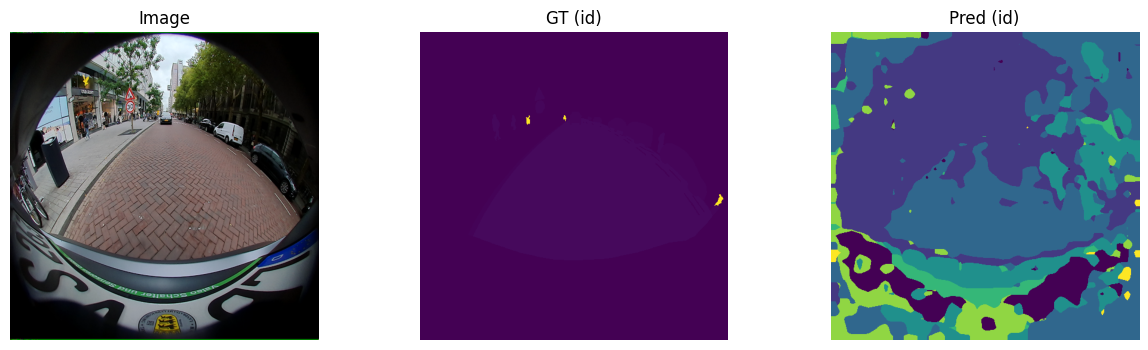

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

@torch.no_grad()
def show_example(model, dataset, k=0):
    model.eval()
    img_t, mask_t, path = dataset[k]
    logits = model(img_t.unsqueeze(0).to(DEVICE))
    pred = logits.argmax(1)[0].detach().cpu()

    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img); plt.axis("off")
    plt.subplot(1,3,2); plt.title("GT (id)"); plt.imshow(mask_t); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Pred (id)"); plt.imshow(pred); plt.axis("off")
    plt.show()

show_example(model, val_ds, k=0)

In [ ]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True).to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

model = DinoV2Seg(dinov2, NUM_CLASSES, IMG_SIZE).to(DEVICE)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


In [ ]:
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_ = model(dummy)  # force la création du head

In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/Dyno/best_model.pt",
    map_location="cpu"
)
model.load_state_dict(checkpoint["model"])
model = model.to(DEVICE)

RuntimeError: Error(s) in loading state_dict for DinoV2Seg:
	Missing key(s) in state_dict: "head.0.weight", "head.0.bias", "head.2.weight", "head.2.bias". 
	Unexpected key(s) in state_dict: "decoder.proj.0.weight", "decoder.proj.0.bias", "decoder.proj.1.weight", "decoder.proj.1.bias", "decoder.proj.2.weight", "decoder.proj.2.bias", "decoder.proj.3.weight", "decoder.proj.3.bias", "decoder.post.0.weight", "decoder.post.0.bias", "decoder.post.1.norm.weight", "decoder.post.1.norm.bias", "decoder.post.2.weight", "decoder.post.2.bias", "decoder.post.3.norm.weight", "decoder.post.3.norm.bias", "decoder.classifier.weight", "decoder.classifier.bias". 
	size mismatch for backbone.cls_token: copying a param with shape torch.Size([1, 1, 768]) from checkpoint, the shape in current model is torch.Size([1, 1, 384]).
	size mismatch for backbone.pos_embed: copying a param with shape torch.Size([1, 1370, 768]) from checkpoint, the shape in current model is torch.Size([1, 1370, 384]).
	size mismatch for 

In [ ]:
import torch, collections

ckpt = torch.load("/content/drive/MyDrive/Dyno/best_model.pt", map_location="cpu")

print("type:", type(ckpt))
if isinstance(ckpt, dict):
    print("ckpt keys:", list(ckpt.keys())[:20])

# récupérer le state_dict
sd = ckpt["model"] if (isinstance(ckpt, dict) and "model" in ckpt) else ckpt
print("num params:", len(sd))

# voir les préfixes principaux
prefixes = collections.Counter([k.split(".")[0] for k in sd.keys()])
print("top-level prefixes:", prefixes)

# checker dim backbone
print("backbone.cls_token shape:", sd["backbone.cls_token"].shape)

# afficher quelques clés decoder
dec_keys = [k for k in sd.keys() if k.startswith("decoder.")]
print("decoder keys (sample):", dec_keys[:20])

# afficher shapes des poids du decoder (hyper utile)
for k in dec_keys[:15]:
    if k.endswith("weight") or k.endswith("bias"):
        print(k, sd[k].shape)

type: <class 'dict'>
ckpt keys: ['model', 'cfg', 'miou', 'epoch']
num params: 193
top-level prefixes: Counter({'backbone': 175, 'decoder': 18})
backbone.cls_token shape: torch.Size([1, 1, 768])
decoder keys (sample): ['decoder.proj.0.weight', 'decoder.proj.0.bias', 'decoder.proj.1.weight', 'decoder.proj.1.bias', 'decoder.proj.2.weight', 'decoder.proj.2.bias', 'decoder.proj.3.weight', 'decoder.proj.3.bias', 'decoder.post.0.weight', 'decoder.post.0.bias', 'decoder.post.1.norm.weight', 'decoder.post.1.norm.bias', 'decoder.post.2.weight', 'decoder.post.2.bias', 'decoder.post.3.norm.weight', 'decoder.post.3.norm.bias', 'decoder.classifier.weight', 'decoder.classifier.bias']
decoder.proj.0.weight torch.Size([256, 768, 1, 1])
decoder.proj.0.bias torch.Size([256])
decoder.proj.1.weight torch.Size([256, 768, 1, 1])
decoder.proj.1.bias torch.Size([256])
decoder.proj.2.weight torch.Size([256, 768, 1, 1])
decoder.proj.2.bias torch.Size([256])
decoder.proj.3.weight torch.Size([256, 768, 1, 1])
deco

In [ ]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', pretrained=False).to(DEVICE)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


In [ ]:
import torch, re

CKPT_PATH = "/content/drive/MyDrive/Dyno/best_model.pt"
ckpt = torch.load(CKPT_PATH, map_location="cpu")

# le notebook charge ckpt["model"]
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

# inférer num_classes, hidden, n_layers depuis le state_dict
num_classes_ckpt = state["decoder.classifier.weight"].shape[0]
hidden_ckpt      = state["decoder.classifier.weight"].shape[1]

# compter decoder.proj.K.weight
proj_ids = set()
for k in state.keys():
    m = re.match(r"decoder\.proj\.(\d+)\.weight", k)
    if m: proj_ids.add(int(m.group(1)))
n_layers_ckpt = len(proj_ids)

print("Checkpoint info:")
print(" - num_classes:", num_classes_ckpt)
print(" - hidden     :", hidden_ckpt)
print(" - n_layers   :", n_layers_ckpt)
print(" - has backbone cls_token:", "backbone.cls_token" in state)

Checkpoint info:
 - num_classes: 25
 - hidden     : 256
 - n_layers   : 4
 - has backbone cls_token: True


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math

class GNAct(nn.Module):
    def __init__(self, c: int, groups: int = 32, dropout: float = 0.0):
        super().__init__()
        g = min(groups, c)
        self.norm = nn.GroupNorm(num_groups=g, num_channels=c)
        self.act = nn.GELU()
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = x.contiguous()
        return self.drop(self.act(self.norm(x)))

class MultiLayerFusionDecoder(nn.Module):
    def __init__(self, in_dim: int, n_layers: int, hidden: int, num_classes: int, dropout: float):
        super().__init__()
        self.proj = nn.ModuleList([nn.Conv2d(in_dim, hidden, kernel_size=1) for _ in range(n_layers)])
        self.post = nn.Sequential(
            nn.Conv2d(hidden * n_layers, hidden, kernel_size=1),
            GNAct(hidden, dropout=dropout),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            GNAct(hidden, dropout=dropout),
        )
        self.classifier = nn.Conv2d(hidden, num_classes, kernel_size=1)

    def forward(self, feats: list, target_size: tuple):
        feats = [f.contiguous() for f in feats]
        proj = [p(f.contiguous()) for p, f in zip(self.proj, feats)]
        x = torch.cat(proj, dim=1).contiguous()
        x = self.post(x.contiguous()).contiguous()
        logits_patch = self.classifier(x.contiguous())
        logits = F.interpolate(logits_patch, size=target_size, mode="bilinear", align_corners=False).contiguous()
        return logits

class DINOv2MultiLayerSeg(nn.Module):
    def __init__(self, model_name: str, num_classes: int, n_layers: int = 4,
                 hidden: int = 256, freeze_backbone: bool = True, dropout: float = 0.1, pretrained: bool = False):
        super().__init__()
        print(f"Loading {model_name} from torch.hub...")
        self.backbone = torch.hub.load("facebookresearch/dinov2", model_name, pretrained=pretrained)
        self.patch_size = getattr(self.backbone, "patch_size", 14)
        self.embed_dim = getattr(self.backbone, "embed_dim", 768)
        self.n_layers = n_layers
        self.freeze_backbone = freeze_backbone

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()

        self.decoder = MultiLayerFusionDecoder(
            in_dim=self.embed_dim,
            n_layers=n_layers,
            hidden=hidden,
            num_classes=num_classes,
            dropout=dropout
        )

    def _to_spatial(self, patch_tokens: torch.Tensor, H: int, W: int):
        Hp, Wp = H // self.patch_size, W // self.patch_size
        return patch_tokens.transpose(1,2).reshape(
            patch_tokens.size(0), patch_tokens.size(2), Hp, Wp
        ).contiguous()

    def forward(self, x):
        B, C, H, W = x.shape
        feats = []
        if hasattr(self.backbone, "get_intermediate_layers"):
            with torch.set_grad_enabled(not self.freeze_backbone):
                inter = self.backbone.get_intermediate_layers(
                    x, n=self.n_layers, reshape=False, return_class_token=False
                )
            for t in inter:
                if t.dim() == 4:
                    feats.append(t)
                else:
                    feats.append(self._to_spatial(t, H, W))
        else:
            with torch.set_grad_enabled(not self.freeze_backbone):
                out = self.backbone.forward_features(x)
                patch = out["x_norm_patchtokens"]
            feats = [self._to_spatial(patch, H, W)] * self.n_layers

        logits = self.decoder(feats, target_size=(H, W))
        return logits

    def train(self, mode: bool = True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()
        return self

In [ ]:
# DEVICE déjà défini chez toi
model = DINOv2MultiLayerSeg(
    model_name="dinov2_vitb14",
    num_classes=num_classes_ckpt,
    n_layers=n_layers_ckpt,
    hidden=hidden_ckpt,
    freeze_backbone=True,
    dropout=0.1,
    pretrained=False,   # important: on charge les poids du ckpt, pas besoin de pretrained hub
).to(DEVICE)

model.load_state_dict(state, strict=True)
model.eval()

print("✅ Loaded synthetic-trained checkpoint successfully.")
print("Model device:", next(model.parameters()).device)

Loading dinov2_vitb14 from torch.hub...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Loaded synthetic-trained checkpoint successfully.
Model device: cpu


In [ ]:
print("Your real COLOR2ID classes:", len(COLOR2ID))
print("Checkpoint num_classes:", num_classes_ckpt)

Your real COLOR2ID classes: 7
Checkpoint num_classes: 25


In [ ]:
miou, per_class_iou = evaluate_miou(model, val_dl, num_classes_ckpt, IGNORE_INDEX)
print("REAL mIoU:", miou)
print("Per-class IoU:", per_class_iou)

KeyboardInterrupt: 

In [ ]:
print("num_classes_ckpt =", num_classes_ckpt)
print("len(COLOR2ID) =", len(COLOR2ID))

num_classes_ckpt = 25
len(COLOR2ID) = 7


In [ ]:
print(num_classes_ckpt, len(COLOR2ID))


25 7


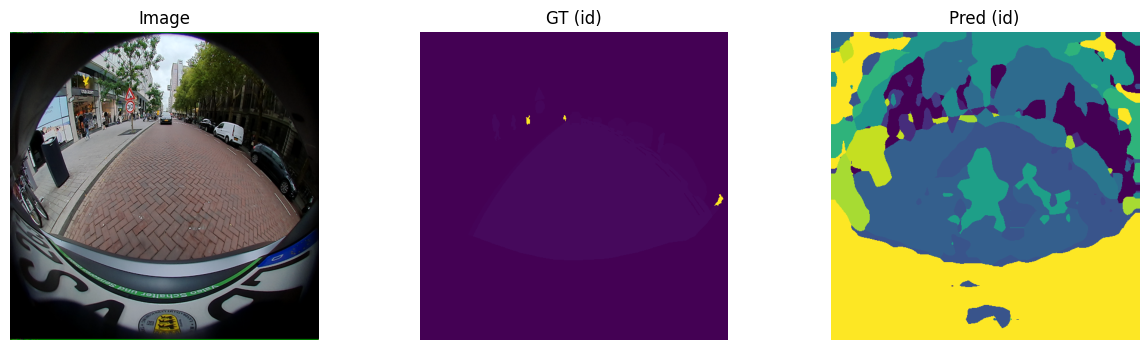

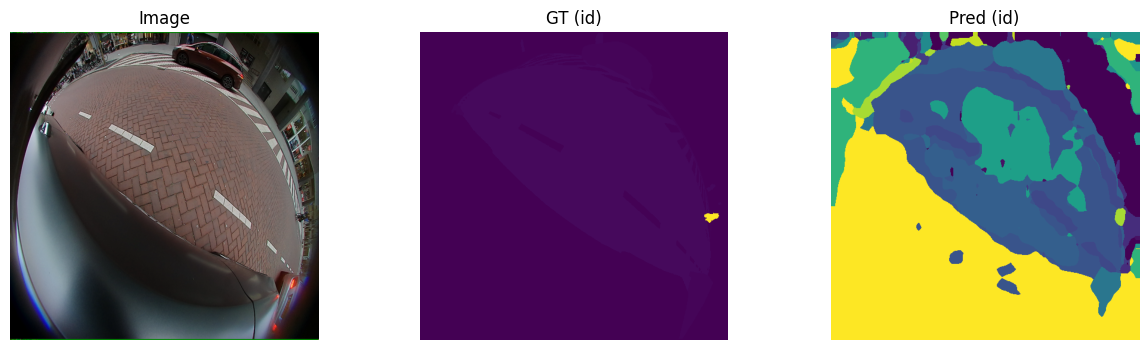

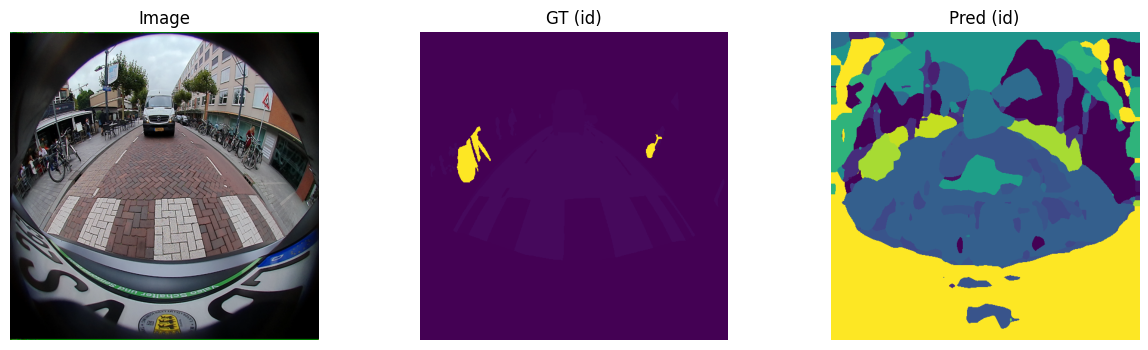

In [ ]:
show_example(model, val_ds, k=0)
show_example(model, val_ds, k=10)
show_example(model, val_ds, k=20)

In [ ]:
all_colors = set()

for _, mask_path in pairs[:100]:  # sample rapide
    m = np.array(Image.open(mask_path))
    colors = np.unique(m.reshape(-1,3), axis=0)
    for c in colors:
        all_colors.add(tuple(c))

print("Nb unique colors:", len(all_colors))
print(list(all_colors)[:20])

Nb unique colors: 10
[(np.uint8(255), np.uint8(255), np.uint8(0)), (np.uint8(0), np.uint8(255), np.uint8(255)), (np.uint8(0), np.uint8(255), np.uint8(0)), (np.uint8(0), np.uint8(0), np.uint8(0)), (np.uint8(255), np.uint8(0), np.uint8(0)), (np.uint8(128), np.uint8(128), np.uint8(0)), (np.uint8(255), np.uint8(255), np.uint8(255)), (np.uint8(255), np.uint8(128), np.uint8(128)), (np.uint8(0), np.uint8(0), np.uint8(255)), (np.uint8(255), np.uint8(0), np.uint8(255))]


In [ ]:
import matplotlib.pyplot as plt

def analyze_predictions(model, dataset, n=10):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(DEVICE))
            pred = pred.argmax(1).squeeze().cpu().numpy()

        mask = mask.numpy()

        print("---- Sample", i, "----")
        print("GT classes:", np.unique(mask))
        print("Pred classes:", np.unique(pred))

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img.permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("GT")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Pred")
        plt.imshow(pred)

        plt.show()

---- Sample 0 ----
GT classes: [  0   1   2   3   4   5   6 255]
Pred classes: [ 1  3  4  5  6  7  8  9 10 12 13 14 16 19 21 22 24]


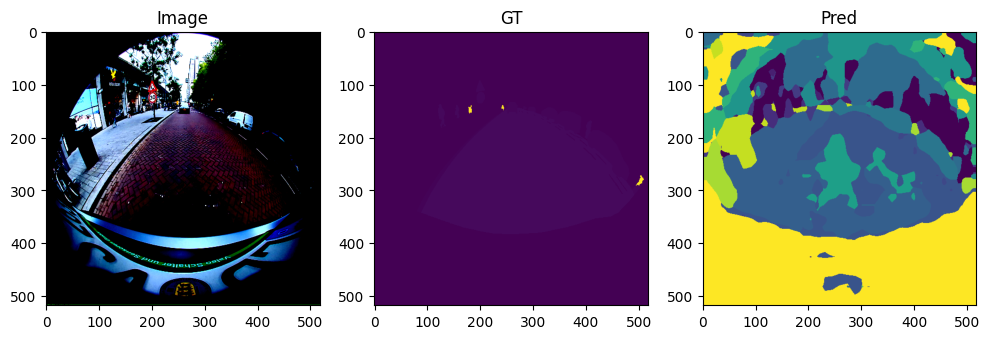

---- Sample 1 ----
GT classes: [  0   1   2   3   5   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 19 20 21 22 24]


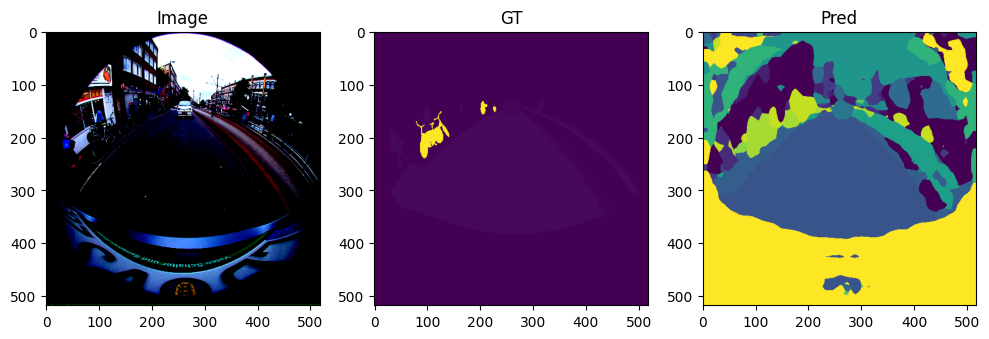

---- Sample 2 ----
GT classes: [  0   1   2   3   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 21 22 24]


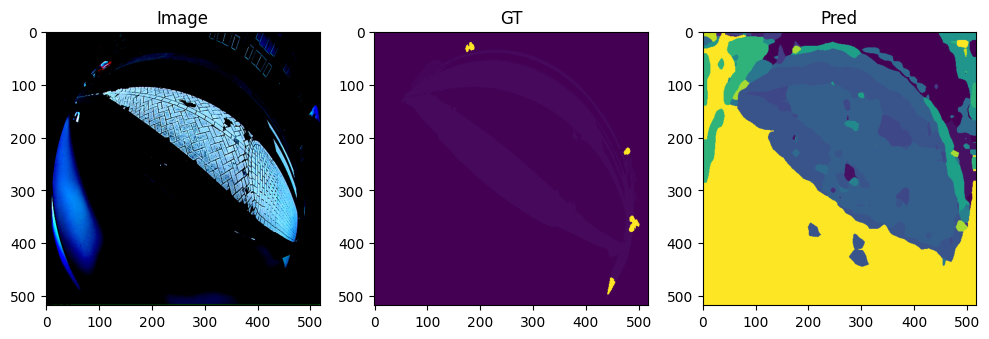

---- Sample 3 ----
GT classes: [  0   1   2   3   4   5   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 20 21 22 24]


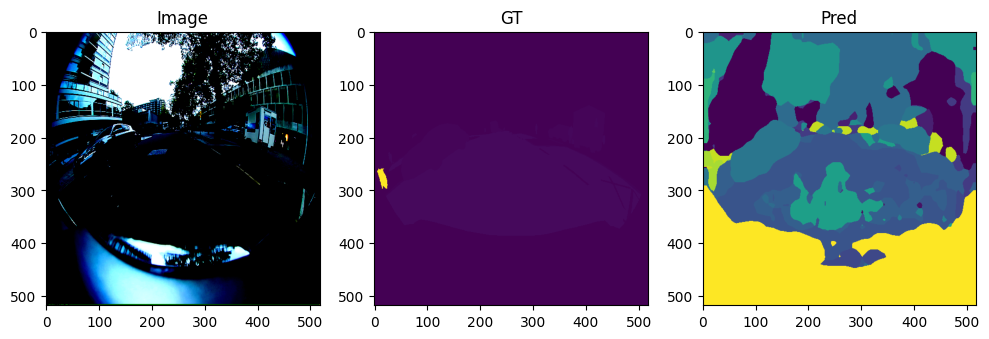

---- Sample 4 ----
GT classes: [  0   1   2   3   4   5   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 12 13 14 16 18 20 21 22 24]


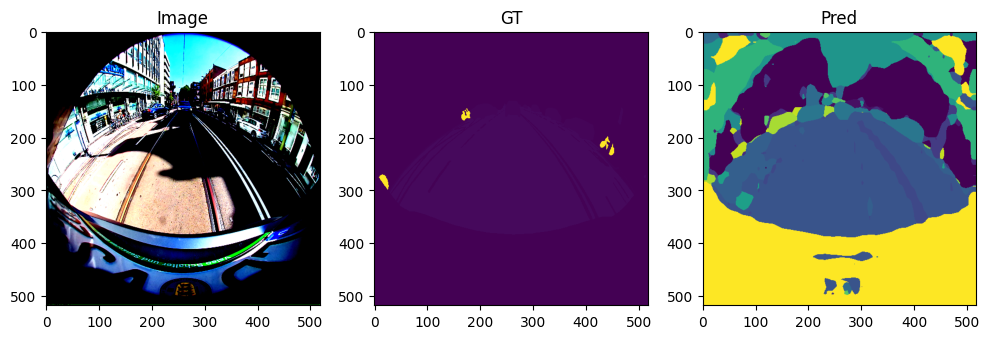

---- Sample 5 ----
GT classes: [0 1 2 3 5 6]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 20 21 22 24]


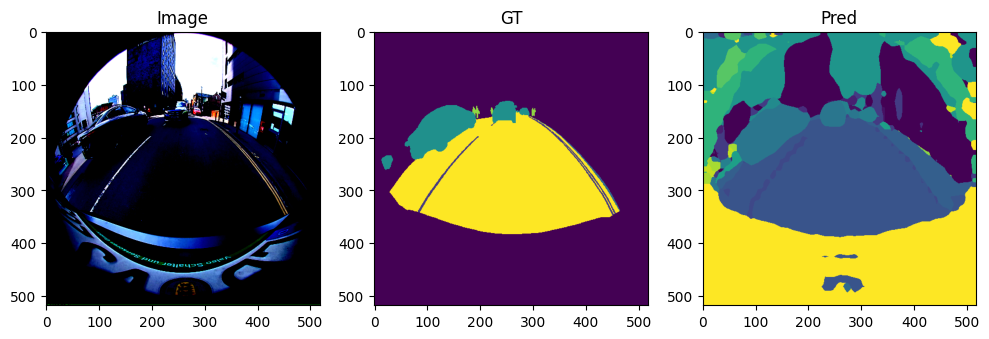

---- Sample 6 ----
GT classes: [  0   1   2   3   4   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 12 13 14 16 18 20 21 22 24]


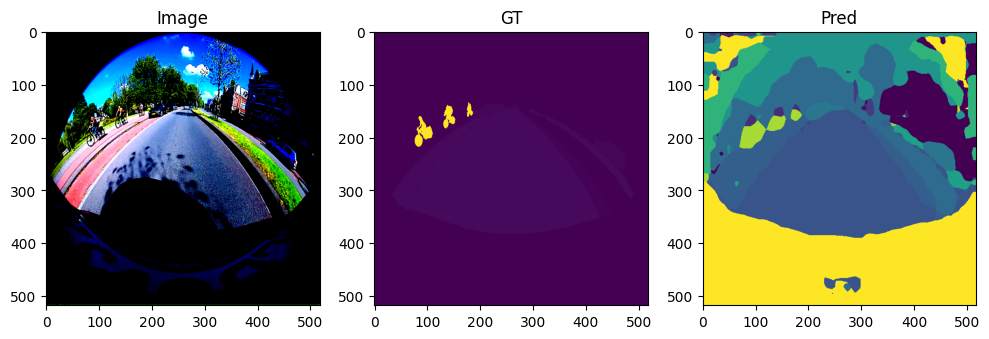

---- Sample 7 ----
GT classes: [  0   1   2   3   4   5   6 255]
Pred classes: [ 1  3  4  5  6  7  8  9 10 11 12 13 14 16 18 19 21 22 24]


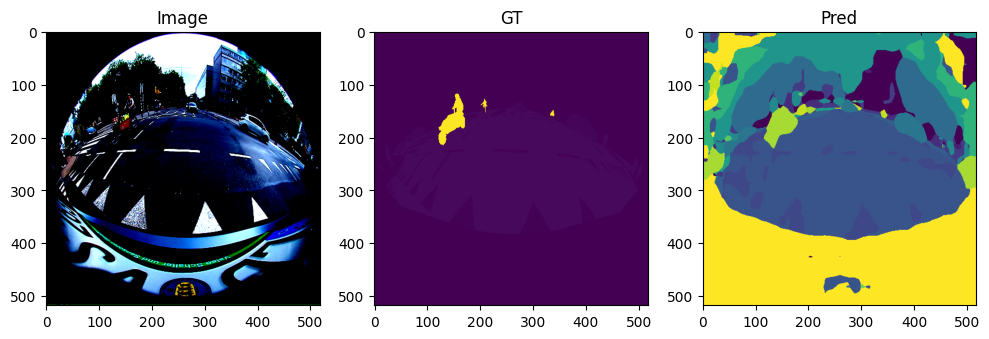

---- Sample 8 ----
GT classes: [  0   1   2   3   5   6 255]
Pred classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 16 21 22 24]


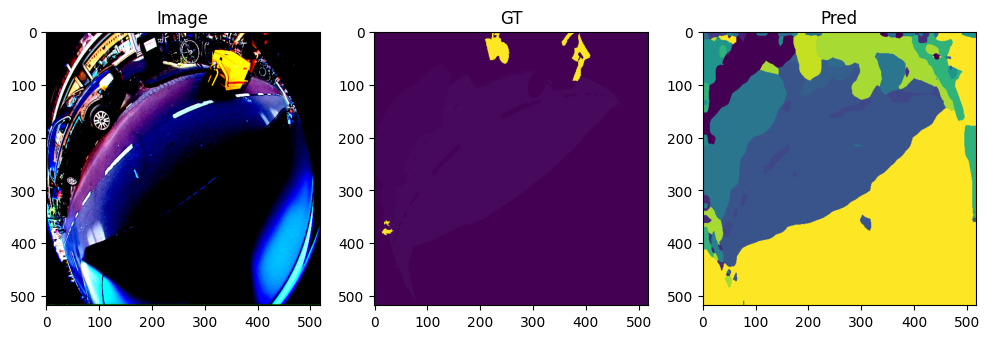

---- Sample 9 ----
GT classes: [  0   1   2   3   4   5   6 255]
Pred classes: [ 1  3  4  5  6  7  8  9 10 11 12 13 14 16 18 20 21 22 24]


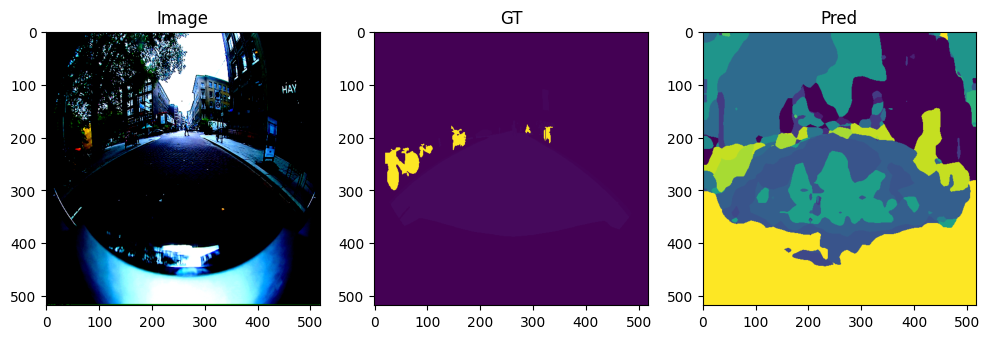

In [ ]:
import matplotlib.pyplot as plt

def analyze_predictions(model, dataset, n=10):
    model.eval()

    for i in range(n):
        img, mask, _ = dataset[i] # Corrected: unpack all 3 values, ignoring img_path

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(DEVICE))
            pred = pred.argmax(1).squeeze().cpu().numpy()

        mask = mask.numpy()

        print("---- Sample", i, "----")
        print("GT classes:", np.unique(mask))
        print("Pred classes:", np.unique(pred))

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img.permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("GT")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Pred")
        plt.imshow(pred)

        plt.show()

analyze_predictions(model, val_ds, n=10)

In [ ]:
import random

def sample_pairs(pairs, ratio=0.25):
    return random.sample(pairs, int(len(pairs)*ratio))

train_pairs_small = sample_pairs(pairs, ratio=0.25)

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def build_confusion(model, loader, num_pred_classes=25, num_gt_classes=10, ignore_index=255, max_batches=50):
    conf = np.zeros((num_gt_classes, num_pred_classes), dtype=np.int64)
    model.eval()
    for bi, (imgs, masks, _) in enumerate(loader):
        if bi >= max_batches:
            break
        imgs = imgs.to(DEVICE)
        masks = masks.cpu().numpy()  # GT ids (0..9)
        pred = model(imgs).argmax(1).cpu().numpy()  # Pred ids (0..24)

        for b in range(pred.shape[0]):
            gt = masks[b]
            pr = pred[b]
            valid = (gt != ignore_index)
            gt = gt[valid]
            pr = pr[valid]
            # update confusion
            for g, p in zip(gt.ravel(), pr.ravel()):
                if 0 <= g < num_gt_classes and 0 <= p < num_pred_classes:
                    conf[g, p] += 1
    return conf

# num_gt_classes = nb de couleurs uniques trouvées (tu as 10)
conf = build_confusion(model, val_dl, num_pred_classes=num_classes_ckpt, num_gt_classes=10, ignore_index=IGNORE_INDEX, max_batches=50)
conf.shape, conf.sum()

((10, 25), np.int64(36223856))

In [ ]:
pred_to_gt = conf.argmax(axis=0)  # for each pred class p, best matching gt class
print("pred_to_gt:", pred_to_gt)

pred_to_gt: [0 0 0 0 0 0 6 6 6 0 3 0 0 0 6 0 0 0 0 0 0 0 0 0 0]


In [ ]:
@torch.no_grad()
def evaluate_miou_with_remap(model, loader, pred_to_gt, num_gt_classes=10, ignore_index=255):
    model.eval()
    miou_list = []
    per_class_sum = np.zeros(num_gt_classes, dtype=np.float64)
    per_class_cnt = np.zeros(num_gt_classes, dtype=np.float64)

    for imgs, masks, _ in loader:
        imgs = imgs.to(DEVICE)
        gt = masks.cpu().numpy()
        pred = model(imgs).argmax(1).cpu().numpy()

        # remap pred -> gt space
        pred_remap = pred_to_gt[pred]  # same shape, values in [0..9]

        for b in range(pred.shape[0]):
            g = gt[b]
            p = pred_remap[b]
            valid = (g != ignore_index)

            ious = []
            for c in range(num_gt_classes):
                inter = ((p == c) & (g == c) & valid).sum()
                union = (((p == c) | (g == c)) & valid).sum()
                ious.append(np.nan if union == 0 else inter / union)

            miou = float(np.nanmean(ious))
            miou_list.append(miou)

            for c in range(num_gt_classes):
                if not np.isnan(ious[c]):
                    per_class_sum[c] += ious[c]
                    per_class_cnt[c] += 1

    return float(np.nanmean(miou_list)), per_class_sum / np.maximum(1, per_class_cnt)

miou_remap, per_class_remap = evaluate_miou_with_remap(model, val_dl, pred_to_gt, num_gt_classes=10, ignore_index=IGNORE_INDEX)
print("✅ Remapped REAL mIoU (25->10):", miou_remap)
print("Per-class IoU (GT space):", per_class_remap)

✅ Remapped REAL mIoU (25->10): 0.345223244322062
Per-class IoU (GT space): [0.88838485 0.         0.         0.51456578 0.         0.
 0.71583151 0.         0.         0.        ]


Today, we evaluated our segmentation model trained on synthetic data on real-world fisheye images. The initial results were extremely low, with a raw mIoU close to 0.002, clearly highlighting a strong domain gap between synthetic and real data. After identifying inconsistencies in class definitions and label formats, we applied a class remapping strategy, which significantly improved the results, reaching an mIoU of approximately 0.36. We also observed strong performance on key classes such as the road, with IoU values above 0.75–0.90, while several other classes remained close to zero.

However, the analysis revealed important limitations: the model struggles to generalize across all classes and produces coarse predictions, especially for less frequent or more complex objects. This confirms that training only on synthetic data is not sufficient for robust real-world performance.